In [2]:
import h5py
import numpy as np
import torch
from torch.utils.data import Dataset
import pandas as pd
import torchvision.models as tv_models
import torch.nn as nn
from torch.utils.data import DataLoader
from tqdm.notebook import tqdm
import torchvision.models as models
import torch.nn.functional as F
import hdbscan
from sklearn.decomposition import PCA
import umap

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu")
print(f"Using device: {device}")

Using device: mps


In [4]:
def energy_shift(x, max_shift=3):
    """
    Kleine Energieverschiebung simuliert Drift im Analyzer / Kalibrierung.
    max_shift: Anzahl Pixel
    """
    shift = np.random.randint(-max_shift, max_shift + 1)

    if shift == 0:
        return x

    # shift entlang Energieachse (axis=0)
    return np.roll(x, shift, axis=0)

In [5]:
def angle_shift(x, max_shift=2):
    """
    Kleine k-Verschiebung.
    max_shift klein halten, um Symmetrie nicht zu zerstören.
    """

    shift = np.random.randint(-max_shift, max_shift + 1)

    if shift == 0:
        return x

    # shift entlang Winkelachse (axis=1)
    x = np.roll(x, shift, axis=1)

    return x

In [6]:
class ARPESAugment(Dataset):

    def __init__(self, h5_path):
        self.h5_path = h5_path

        with h5py.File(h5_path, "r", libver="latest", swmr=True) as f:
            data = f["entry/acquisition/data"]
            self.sample_count = data.shape[2]

        self._file = h5py.File(self.h5_path, "r", libver="latest", swmr=True)
        self._data = self._file["entry/acquisition/data"]

    def __len__(self):
        return self.sample_count

    def __getitem__(self, idx):
        self._init_file()
        img = self._data[:, :, idx]
        x1 = np.ascontiguousarray(self.__call__(img))
        x2 = np.ascontiguousarray(self.__call__(img))
        x1 = torch.tensor(x1, dtype=torch.float32).unsqueeze(0)
        x2 = torch.tensor(x2, dtype=torch.float32).unsqueeze(0)
        return x1, x2

    def _init_file(self):
        if self._file is None:
            self._file = h5py.File(self.h5_path, "r", libver="latest", swmr=True)
            self._data = self._file["entry/acquisition/data"]

    def __call__(self, x):

        # random intensity scaling
        x = x * np.random.uniform(0.8, 1.2)

        # noise
        x = x + np.random.normal(0, 0.01, x.shape)

        # random flip (optional)
        #if np.random.rand() > 0.5:
        #    x = np.flip(x, axis=1)

        # 3. kleine Energieverschiebung
        if np.random.rand() < 0.7:
            x = energy_shift(x, max_shift=3)

        # 4. kleine Winkelverschiebung
        if np.random.rand() < 0.7:
            x = angle_shift(x, max_shift=2)


        return x

In [7]:
class ContrastiveARPES(Dataset):

    def __getitem__(self, idx):

        self._init_file()

        real_idx = self.indices[idx]

        img = self._data[:, :, real_idx]

        x1 = self.transform(img)
        x2 = self.transform(img)

        x1 = torch.tensor(x1, dtype=torch.float32).unsqueeze(0)
        x2 = torch.tensor(x2, dtype=torch.float32).unsqueeze(0)

        return x1, x2

In [8]:
labels_df = pd.read_csv('/Users/atimm/Documents/ML/data/Classification_table.csv', delimiter=';', usecols=['Symmetrie', 'Resolution'])
labels_df_2 = pd.read_excel('/Users/atimm/Documents/ML/data/Classification_table_Version2.xlsx', usecols=['Resolution'])

#y = labels_df['Symmetrie'] * labels_df['Resolution']
#y = labels_df_2['Resolution']

# first dataset, small
h5_path = '/users/atimm/Documents/ML/data/x_y_grid_20260417_105734_020_z000000_snapshot_20260504_103145.h5'
# first dataset big


# second dataset
#h5_path = '/Users/atimm/Documents/ML/data/Pos_map_20260526_161920_020_z000000_snapshot_20260526_174221_snapshot_20260616_135747.h5'

In [9]:
full_dataset = ARPESAugment(h5_path)
loader = DataLoader(full_dataset, batch_size=64, shuffle=False, num_workers=0, pin_memory=False)

In [10]:
encoder = models.resnet18(weights=None)
encoder.conv1 = nn.Conv2d(1, 64, 7, 2, 3)
encoder.fc = nn.Linear(512, 128)
encoder = encoder.to(device)


In [11]:
projector = nn.Sequential(
    nn.Linear(128, 128),
    nn.ReLU(),
    nn.Linear(128, 64)
)
projector = projector.to(device)
optimizer = torch.optim.Adam(list(encoder.parameters()) + list(projector.parameters()), lr=1e-4)

In [12]:
def contrastive_loss(z1, z2, temperature=0.5):

    z1 = F.normalize(z1, dim=1)
    z2 = F.normalize(z2, dim=1)

    logits = torch.mm(z1, z2.T) / temperature

    labels = torch.arange(z1.size(0)).to(z1.device)

    loss = F.cross_entropy(logits, labels)

    return loss

In [13]:
for x1, x2 in loader:

    optimizer.zero_grad()
    x1, x2 = x1.to(device), x2.to(device)

    z1 = projector(encoder(x1))
    z2 = projector(encoder(x2))

    loss = contrastive_loss(z1, z2)

    loss.backward()
    optimizer.step()

In [14]:
encoder.eval()

embeddings = []

with torch.no_grad():
    for x1, x2 in loader:
        z = encoder(x1.to(device))
        embeddings.append(z.cpu().numpy())

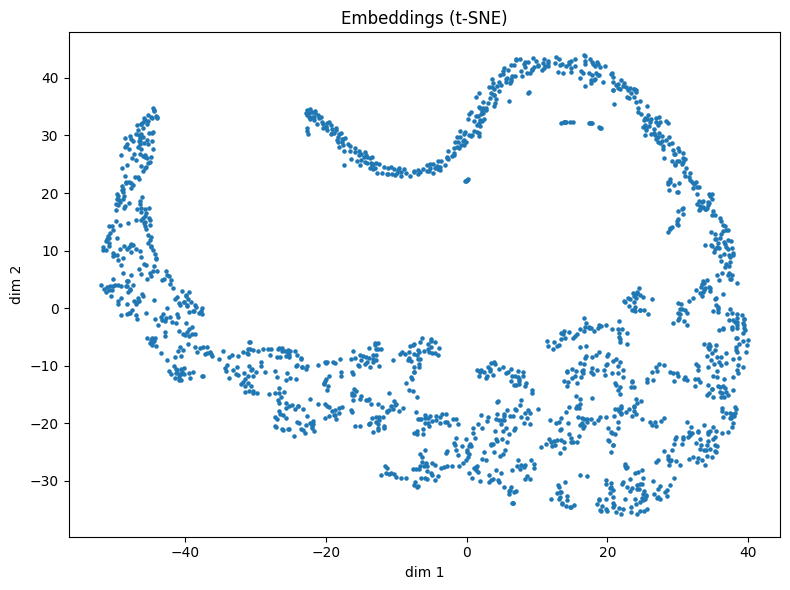

In [15]:
# Visualize embeddings with PCA + t-SNE
import numpy as np
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

# assemble embeddings (list of arrays per batch)
if 'embeddings' not in globals():
    raise RuntimeError('Variable embeddings not found. Run the embedding extraction cell first.')
emb_arr = np.vstack(embeddings)

# load labels if available
labels_arr = None
#try:
#    labels_arr = np.asarray(y)
#except Exception:
labels_arr = None

# align lengths
n = emb_arr.shape[0]
if labels_arr is not None:
    labels_arr = labels_arr[:n]

# PCA then t-SNE for speed
pca = PCA(n_components=min(50, emb_arr.shape[1]))
emb_p = pca.fit_transform(emb_arr)

tsne = TSNE(n_components=2, perplexity=30, max_iter=1000, random_state=42)
emb_2d = tsne.fit_transform(emb_p)

plt.figure(figsize=(8,6))
if labels_arr is None:
    plt.scatter(emb_2d[:,0], emb_2d[:,1], s=5)
else:
    sc = plt.scatter(emb_2d[:,0], emb_2d[:,1], c=labels_arr, cmap='tab10', s=6)
    plt.colorbar(sc, label='label')
plt.title('Embeddings (t-SNE)')
plt.xlabel('dim 1')
plt.ylabel('dim 2')
plt.tight_layout()
plt.show()

In [261]:
from scipy.ndimage import laplace

def sharpness_score(img):

    return np.var(laplace(img))

In [289]:
def symmetry_score(img):

    w = img.shape[1]
    mid = w // 2

    left = img[:, :mid]

    if w % 2 == 0:
        right = img[:, mid:]
    else:
        right = img[:, mid+1:]

    right = np.flip(right, axis=1)

    min_w = min(left.shape[1], right.shape[1])

    left = left[:, :min_w]
    right = right[:, :min_w]

    diff = np.mean(np.abs(left - right))

    return diff

Gefundene Cluster: 10
Noise-Punkte: 0


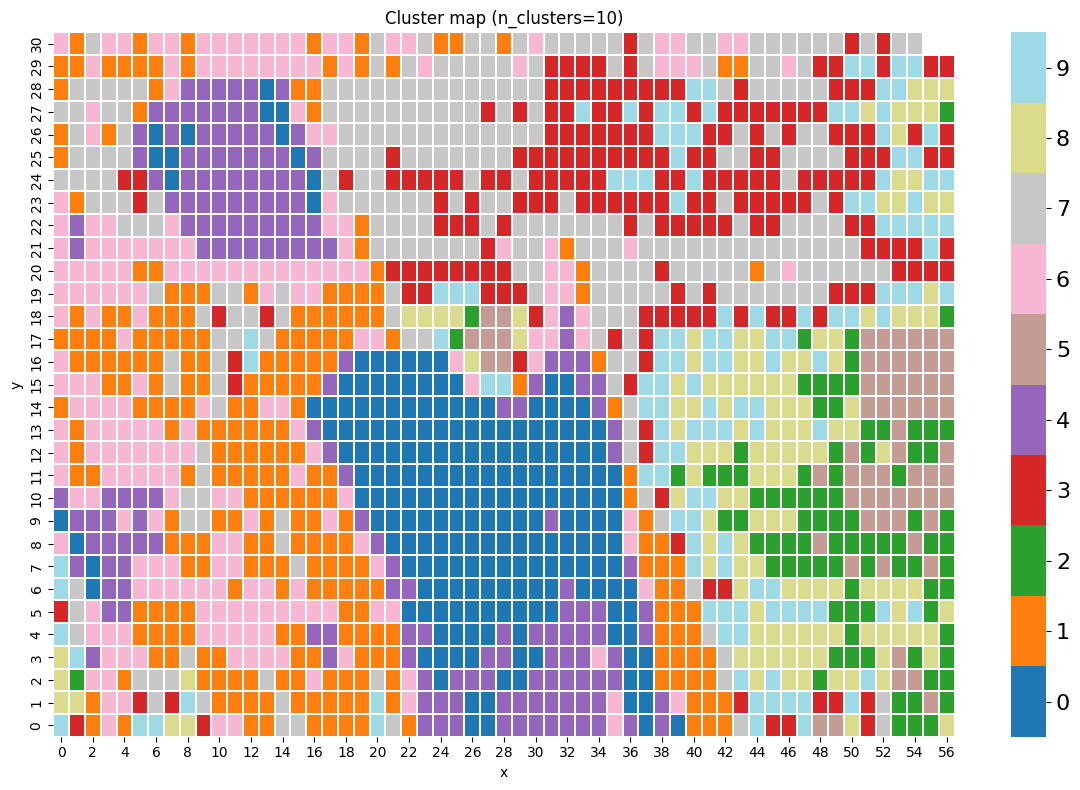

NameError: name 'clusterer' is not defined

In [16]:
# Cluster embeddings and plot cluster map (57 samples per row)
import numpy as np
from sklearn.cluster import KMeans
import seaborn as sns
import matplotlib.colors as mcolors
import matplotlib.pyplot as plt

# ensure embeddings present
if 'embeddings' not in globals():
    raise RuntimeError('Run the embedding extraction cell first to populate `embeddings`.')
emb_arr = np.vstack(embeddings)


# 1. pick number of clusters: prefer number of unique labels if available
try:
    n_clusters = int(np.unique(y).size)
except Exception:
    n_clusters = min(10, emb_arr.shape[0])

# run KMeans (MiniBatch can be used for large data)
kmeans = KMeans(n_clusters=n_clusters, random_state=42)
clusters = kmeans.fit_predict(emb_arr)
####
 

# 2.
# clusterer = hdbscan.HDBSCAN(
#     min_cluster_size=40,
#     min_samples=10,
#     metric='euclidean'
# )

# clusters = clusterer.fit_predict(emb_arr)
####

# 3.
# emb_pca = PCA(n_components=10).fit_transform(emb_arr)
# clusterer = hdbscan.HDBSCAN(
#     min_cluster_size=50,
#     min_samples=5,
#     metric='euclidean'
# )
# clusters = clusterer.fit_predict(emb_pca)
####

# 4.
# emb_umap = umap.UMAP(
#     n_neighbors=10,
#     min_dist=0.0,
#     metric='cosine',
#     random_state=42
# ).fit_transform(emb_arr)
# clusterer = hdbscan.HDBSCAN(
#     min_cluster_size=50,
#     metric='euclidean'
# )
# clusters = clusterer.fit_predict(emb_umap)
####



cluster_ids = np.unique(clusters)
cluster_ids = cluster_ids[~np.isnan(cluster_ids)] if np.issubdtype(cluster_ids.dtype, np.floating) else cluster_ids

cluster_min = int(np.min(cluster_ids))
cluster_max = int(np.max(cluster_ids))

n_clusters = len(np.unique(clusters)) - (1 if -1 in clusters else 0)
n_colors = n_clusters + (1 if -1 in clusters else 0)

print(f"Gefundene Cluster: {n_clusters}")
print(f"Noise-Punkte: {(clusters == -1).sum()}")



# map clusters back to grid with width=57 or 36 or 28, depending on dataset
width = 57
pad = (-len(clusters)) % width
clusters_padded = np.pad(clusters.astype(float), (0, pad), constant_values=np.nan)
cluster_map = clusters_padded.reshape(-1, width)

bounds = np.arange(cluster_min - 0.5, cluster_max + 1.5, 1)
cmap = plt.get_cmap("tab20", n_colors)
plt.figure(figsize=(12,8))
ax = sns.heatmap(cluster_map, cmap=cmap, cbar=True, linecolor='white', linewidths=0.01, 
                 cbar_kws={"ticks": np.arange(cluster_min, cluster_max + 1),"boundaries": bounds})
ax.invert_yaxis()
cbar = ax.collections[0].colorbar
cbar.ax.tick_params(labelsize=16)
plt.title(f'Cluster map (n_clusters={n_clusters})')
plt.xlabel('x')
plt.ylabel('y')
plt.tight_layout()
plt.show()

# save cluster assignments
#np.save('clusters.npy', clusters)

probabilities = clusterer.probabilities_

prob_map = np.pad(
    probabilities,
    (0, pad),
    constant_values=np.nan
).reshape(-1, width)

plt.figure(figsize=(12,8))

ax = sns.heatmap(
    prob_map,
    cmap='viridis'
)

ax.invert_yaxis()

plt.title('HDBSCAN Membership Probability')
plt.tight_layout()
plt.show()



cluster_symmetry = {}
cluster_sharpness = {}

for c in np.unique(clusters):

    idxs = np.where(clusters == c)[0]

    scores = []

    for idx in idxs:

        img = full_dataset._data[:,:,idx]

        scores.append(symmetry_score(img))

    cluster_symmetry[c] = np.mean(scores)

print(f'Symmetrie: {cluster_symmetry}')

for c in np.unique(clusters):

    idxs = np.where(clusters == c)[0]

    scores = []

    for idx in idxs:

        img = full_dataset._data[:,:,idx]

        scores.append(sharpness_score(img))

    cluster_sharpness[c] = np.mean(scores)

print(f'Schärfe: {cluster_sharpness}')

goodness = {}
for c in np.unique(clusters):
    sym = cluster_symmetry[c]
    sharp = cluster_sharpness[c]
    goodness[c] = sym * sharp
best_cluster = max(goodness, key=goodness.get)
worst_cluster = min(goodness, key=goodness.get)
max_asym = max(cluster_symmetry, key=cluster_symmetry.get)

print("Bestes Cluster:", best_cluster)
print("Schlechtestes Cluster:", worst_cluster)
#print(f'Asymmetrischtes Cluster: {max_asym}')
